# Testing av implementering, logistisk regresjon

In [22]:
import numpy as np

### vekter_bias()

In [23]:
from methods import vekter_bias

In [24]:
seed = 270401
W, b = vekter_bias(10, 2)
print(W)
print(b)
print(W.shape)
print(type(b))

[[1.71970109]
 [1.3823945 ]]
-0.7366541159238428
(2, 1)
<class 'float'>


### output()

In [25]:
from methods import output

In [26]:
seed = 42
rng = np.random.default_rng(seed)
X = rng.random((5, 2)) # 5 observasjoner, 2 kovariater
rad, kol = np.shape(X)

W, b = vekter_bias(rad, kol, seed=seed)
print(W.shape, type(b))

#print(np.shape(X@W + b))

y_hat = output(X, W, b)
print(y_hat.shape)

(2, 1) <class 'float'>
(5, 1)


### gradient()

In [27]:
from methods import gradients

In [28]:
n = 5
p = 2
y = rng.random((n, 1))
print(f"Shape y: {y.shape}")
X = rng.random((n, p))
print(f"Shape X: {X.shape}")
W, b = vekter_bias(n, p, seed)
print(f"Shape W: {W.shape}")
print(f"Shape b: {type(b)}")
y_hat = output(X, W, b)
print(f"Shape y_hat: {y_hat.shape}")

dCdW, dCdb = gradients(y, y_hat, X)
print(f"Shape dCdW: {dCdW.shape}")
print(f"Shape dCdb: {dCdb.shape}")



Shape y: (5, 1)
Shape X: (5, 2)
Shape W: (2, 1)
Shape b: <class 'float'>
Shape y_hat: (5, 1)
Shape dCdW: (2, 1)
Shape dCdb: (1,)


### grad_descent()

In [29]:
from methods import gradient_step

In [30]:
W = [(1, 2)]
W = np.array(W).T
print(f"Shape W: {W.shape}")

b = [(1, 2, 3, 4, 5)]
b = np.array(b).T
print(f"Shape b: {b.shape}")

dW = [(1, 2)]
dW = np.array(dW).T
print(f"Shape dW: {dW.shape}")

db = [(1, 2, 3, 4, 5)]
db = np.array(db).T
print(f"Shape db: {db.shape}")

W_afterstep, b_afterstep = gradient_step(W, dW, b, db, eta=1)
print(f"W før: {W}, W etter: {W_afterstep}")
print(f"b før: {b}, b etter: {b_afterstep}")



Shape W: (2, 1)
Shape b: (5, 1)
Shape dW: (2, 1)
Shape db: (5, 1)
W før: [[1]
 [2]], W etter: [[0]
 [0]]
b før: [[1]
 [2]
 [3]
 [4]
 [5]], b etter: [[0]
 [0]
 [0]
 [0]
 [0]]


### fit_model

In [31]:
from methods import fit_model

In [32]:
np.random.seed(0)

n = 200   # antall observasjoner
p = 3     # antall features

# lag X
X = np.random.randn(n, p)

# "sanne" parametre
W_true = np.array([[1.5], [-2.0], [0.5]])
b_true = -0.3

# generer sannsynligheter
z = X @ W_true + b_true
p_true = 1 / (1 + np.exp(-z))

# trekk binær respons
y = (np.random.rand(n,1) < p_true).astype(int)

print(X.shape)  # (200,3)
print(y.shape)  # (200,1)

(200, 3)
(200, 1)


In [33]:
W, b = fit_model(X, y, eta=0.01, n_iters=10000)

print("W:", W)
print("b:", b)

W: [[ 1.54804466]
 [-1.79189893]
 [ 0.44104451]]
b: [-0.58851869]


In [34]:
import matplotlib.pyplot as plt

Lærte vekter:
[[ 2.17815778]
 [-1.39990419]]
Lært bias:
[0.43552705]


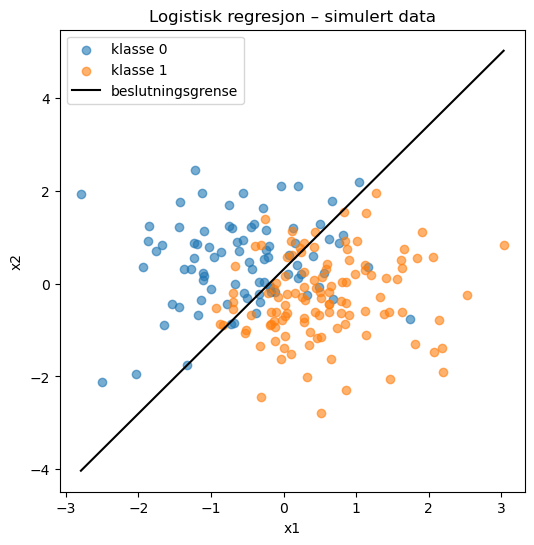

In [35]:
# ---- 1. Simuler data ----
np.random.seed(1)

n = 200
X = np.random.randn(n, 2)

W_true = np.array([[2.0], [-1.0]])
b_true = 0.5

z = X @ W_true + b_true
p = 1 / (1 + np.exp(-z))

y = (np.random.rand(n,1) < p).astype(int)

# ---- 2. Tren modellen ----
W, b = fit_model(X, y, eta=0.01, n_iters=10000)

print("Lærte vekter:")
print(W)
print("Lært bias:")
print(b)

# ---- 3. Plot datapunkter ----
plt.figure(figsize=(6,6))

plt.scatter(
    X[y[:,0] == 0, 0],
    X[y[:,0] == 0, 1],
    label="klasse 0",
    alpha=0.6
)

plt.scatter(
    X[y[:,0] == 1, 0],
    X[y[:,0] == 1, 1],
    label="klasse 1",
    alpha=0.6
)

# ---- 4. Plot beslutningsgrense ----
# Beslutningsgrensen er der sigmoid = 0.5
# altså: W1*x1 + W2*x2 + b = 0

x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

w1 = W[0,0]
w2 = W[1,0]

y_vals = -(w1*x_vals + b)/w2

plt.plot(x_vals, y_vals, color="black", label="beslutningsgrense")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.title("Logistisk regresjon – simulert data")
plt.show()